# EIA-930 Central 40% / Florida 60% Strategy

This notebook reproduces the selected EIA-930 research enhancement from checked-in artifacts. The existing fixed 10% EIA-930 slot is allocated **40% to the Central signal and 60% to the Florida signal**, equivalent to 4% and 6% of the total strategy score. No leverage is added.

The existing GFS wind and solar factors, production-risk state, BSEE/Sabine pure short veto, one-session position lag, and 2.5 bp turnover cost remain unchanged.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

cwd = Path.cwd().resolve()
if (cwd / 'naturalgas/evaluate_eia930_selected_enhancement.py').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'naturalgas/evaluate_eia930_selected_enhancement.py').exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError('Run from the henry-hub-natural-gas repository or notebooks directory.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from naturalgas.evaluate_eia930_selected_enhancement import (
    DEFAULT_EVENT_REPORTS_PATH, DEFAULT_OUTPUT_DIR, FORMAL_DAILY, OVERLAY_INPUTS, run
)

print(f'Project root: {PROJECT_ROOT}')

Project root: /home/syang_braeswoodcarbon_com/2026-intern-projects/henry-hub-natural-gas


## Rebuild from tracked inputs

The evaluator reads the frozen formal strategy, compact Central/Florida overlay, and event registry checked into this repository.

In [2]:
summary = run(
    formal_daily_path=FORMAL_DAILY,
    overlay_inputs_path=OVERLAY_INPUTS,
    event_reports_path=DEFAULT_EVENT_REPORTS_PATH,
    output_dir=DEFAULT_OUTPUT_DIR,
)
print(f"Sample: {summary['sample_start']:%Y-%m-%d} to {summary['sample_end']:%Y-%m-%d}")
print(f"Trading days: {summary['trading_days']:,}")

Sample: 2019-07-25 to 2026-07-13
Trading days: 1,737


## Headline results

In [3]:
rows = []
for version, key in [
    ('Core weather, fundamentals, and veto', 'baseline_metrics'),
    ('Previous 10% Central sleeve', 'current_central_metrics'),
    ('Selected Central 40% / Florida 60%', 'selected_metrics'),
]:
    metric = summary[key]
    rows.append({
        'Version': version,
        'Net Sharpe': metric['sharpe'],
        'Sortino': metric['sortino'],
        'CAGR': metric['cagr'],
        'Maximum drawdown': metric['maximum_drawdown'],
        'Mean absolute position': metric['mean_absolute_position'],
        'Total return': metric['total_return'],
    })
headline = pd.DataFrame(rows).set_index('Version')
display(headline.style.format({
    'Net Sharpe': '{:.3f}', 'Sortino': '{:.3f}', 'CAGR': '{:.2%}',
    'Maximum drawdown': '{:.2%}', 'Mean absolute position': '{:.2%}',
    'Total return': '{:.2%}',
}))

,Net Sharpe,Sortino,CAGR,Maximum drawdown,Mean absolute position,Total return
Version,,,,,,
"Core weather, fundamentals, and veto",1.875,3.195,18.03%,-5.59%,11.50%,217.35%
Previous 10% Central sleeve,1.992,3.329,19.36%,-6.07%,11.73%,243.11%
Selected Central 40% / Florida 60%,2.115,3.643,19.38%,-5.27%,10.80%,243.70%


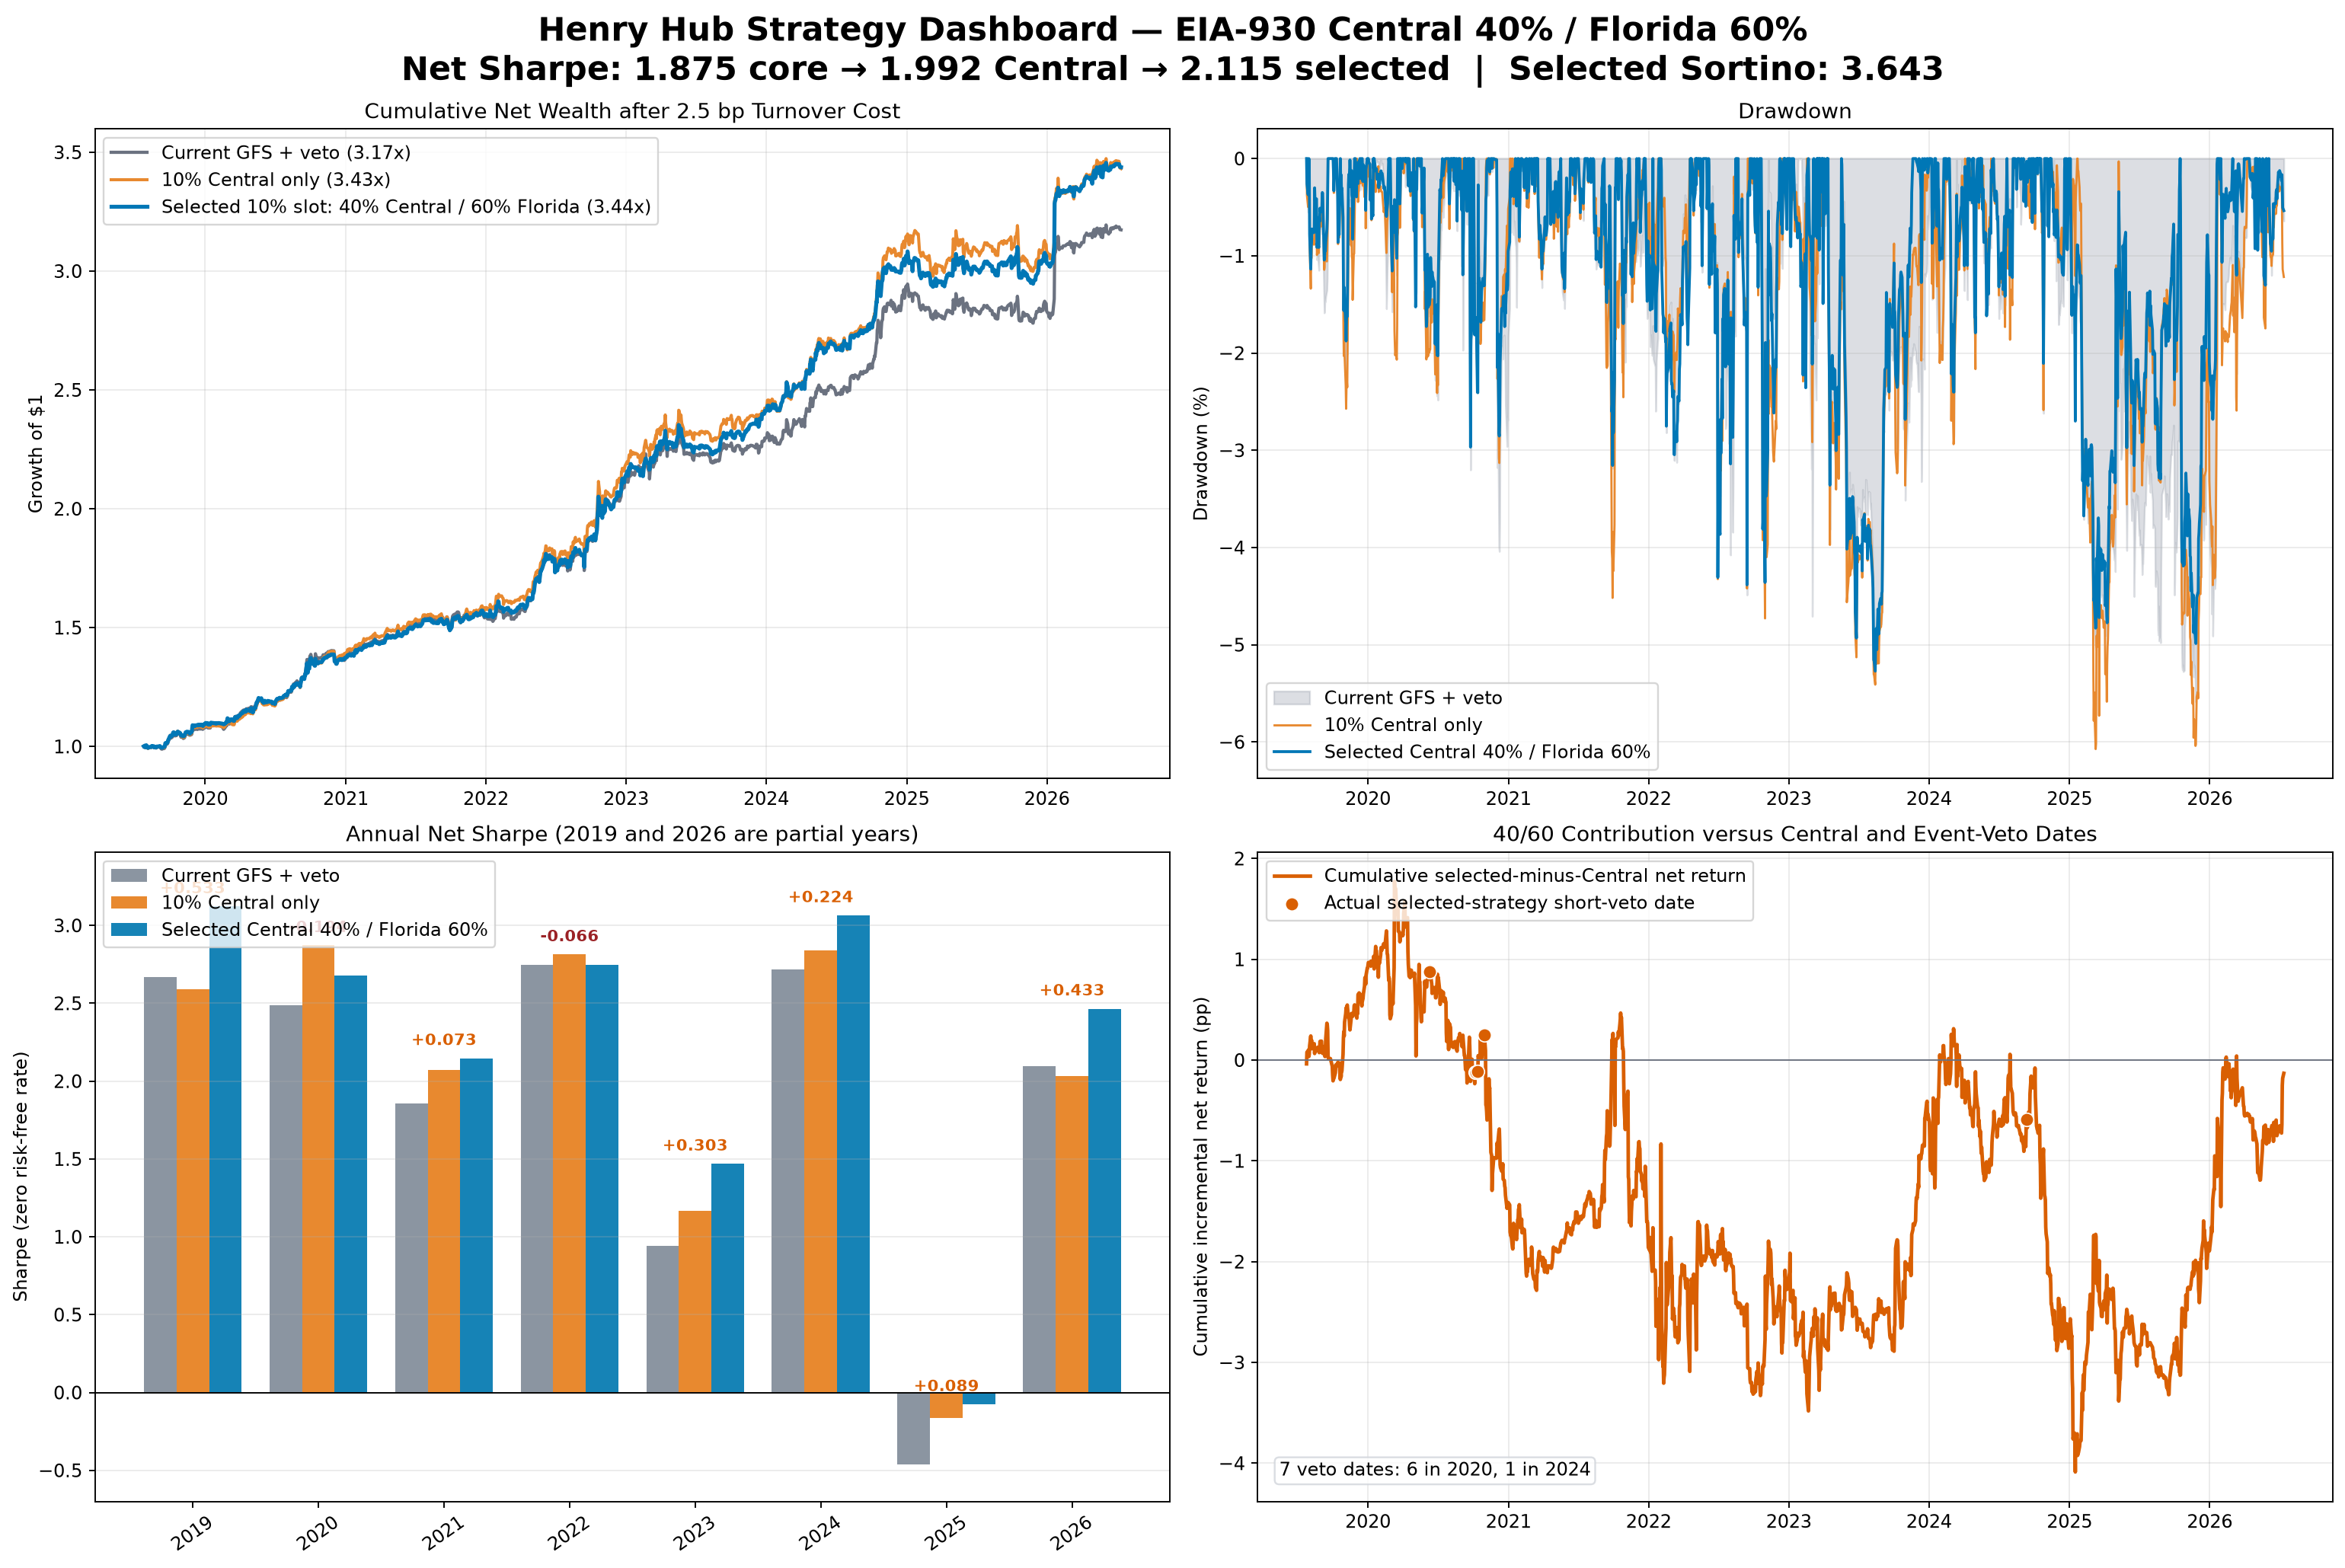

In [4]:
display(Image(filename=str(DEFAULT_OUTPUT_DIR / 'latest_strategy_dashboard.png')))

## Fixed-weight stability

The selected 60% Florida weight is not the ex-post full-sample maximum. It is retained because it has the strongest 2021-2023 validation Sharpe and lies inside the broad 60%-80% Florida plateau.

,Central (%),Florida (%),Full Sharpe,Full Sortino,Development Sharpe,Validation Sharpe,2024+ Sharpe,Maximum drawdown
0,100,0,1.992,3.329,2.785,2.030,1.536,-6.07%
5,50,50,2.104,3.607,2.784,2.117,1.714,-5.29%
6,40,60,2.115,3.643,2.770,2.120,1.745,-5.27%
8,20,80,2.121,3.682,2.730,2.109,1.796,-5.23%
10,0,100,2.108,3.676,2.672,2.079,1.831,-5.18%


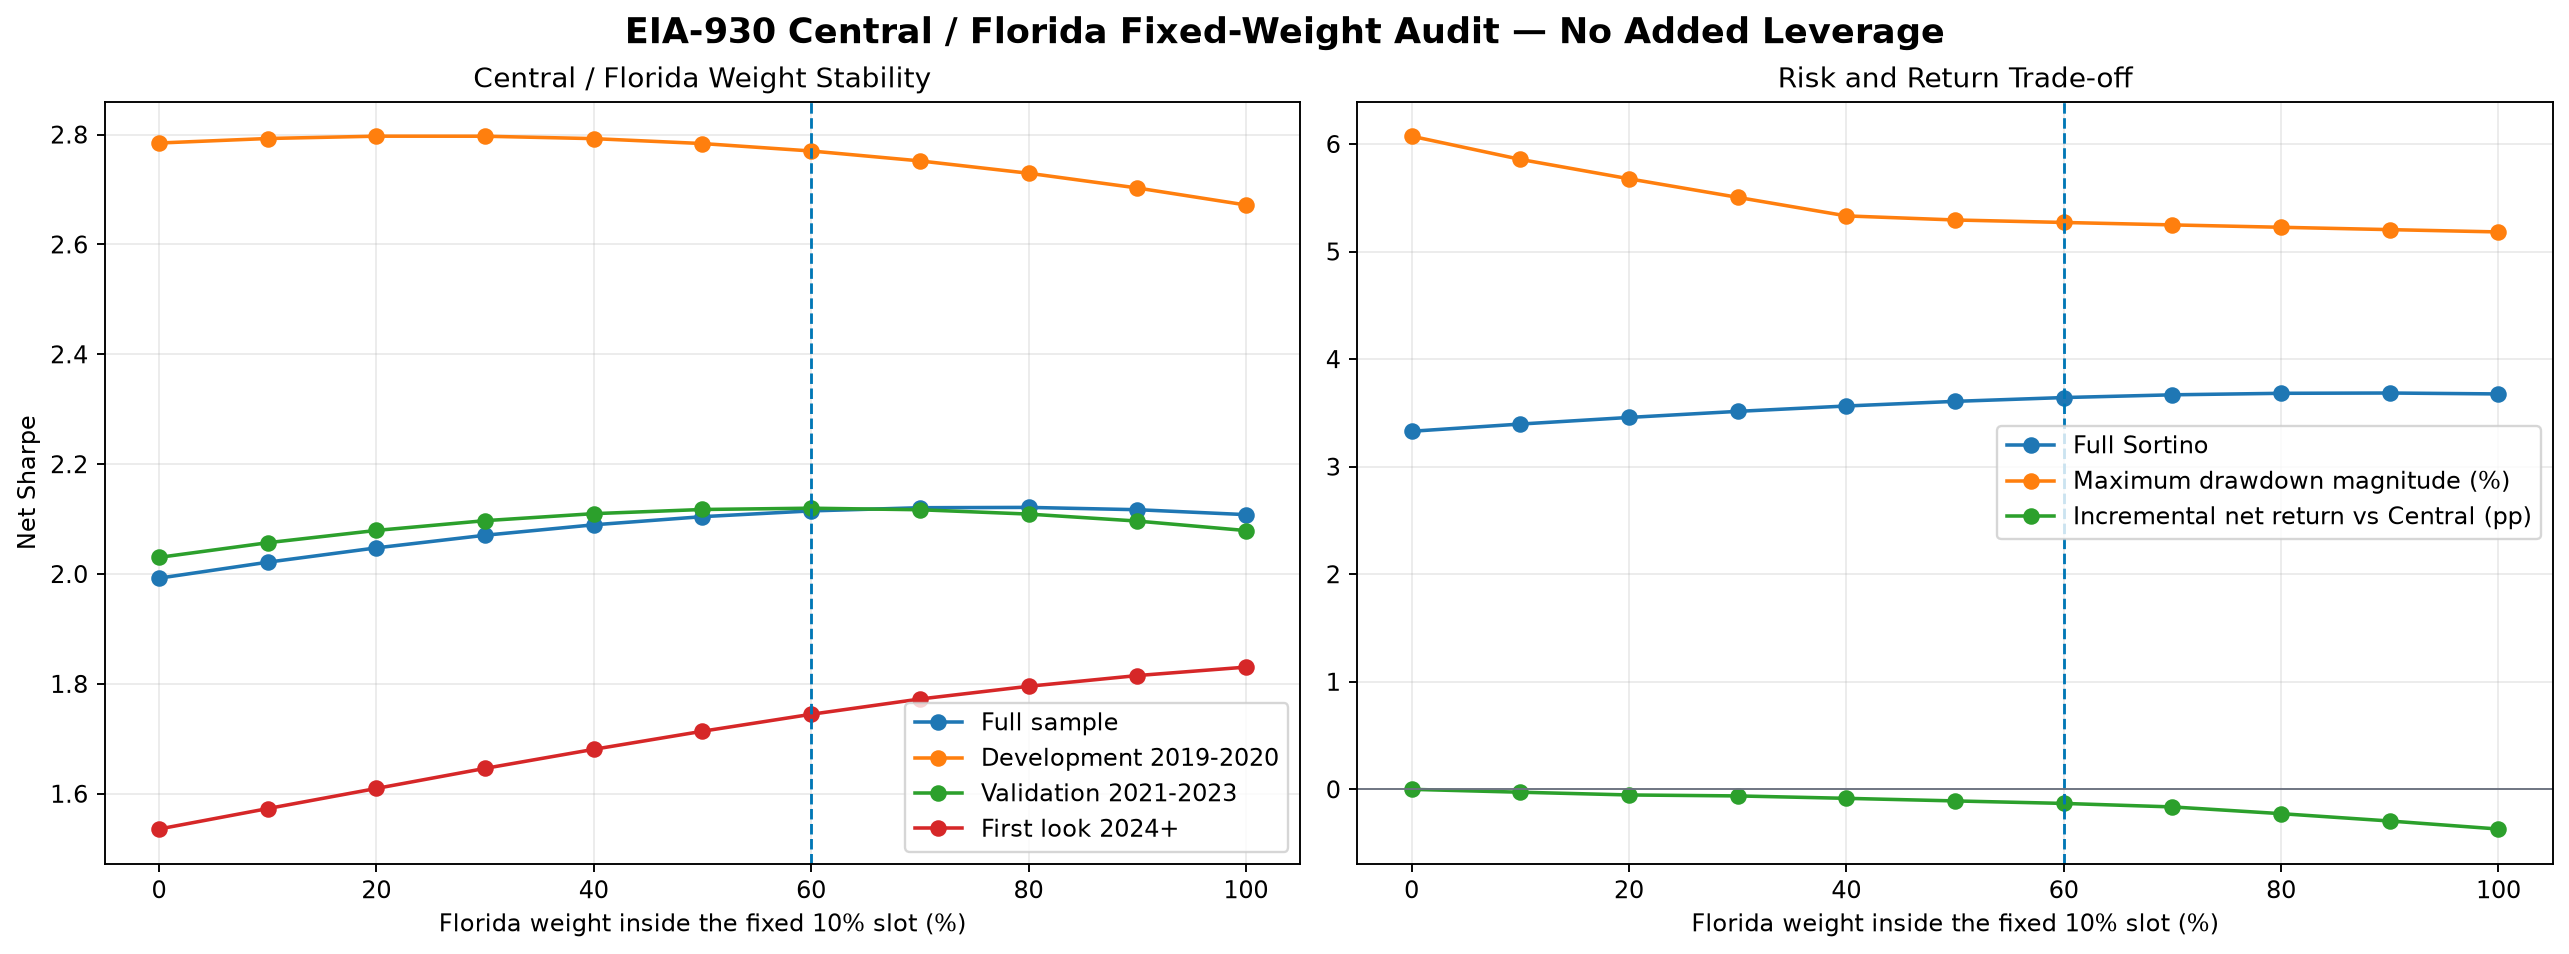

In [5]:
sweep = pd.read_csv(DEFAULT_OUTPUT_DIR / 'central_florida_weight_sweep.csv')
shown = sweep.loc[sweep['florida_weight'].isin([0.0, 0.5, 0.6, 0.8, 1.0]), [
    'central_weight', 'florida_weight', 'full_sharpe', 'full_sortino',
    'development_2019_2020__sharpe', 'validation_2021_2023__sharpe',
    'first_look_2024_plus__sharpe', 'full_maximum_drawdown',
]].copy()
shown['central_weight'] *= 100.0
shown['florida_weight'] *= 100.0
shown = shown.rename(columns={
    'central_weight': 'Central (%)', 'florida_weight': 'Florida (%)',
    'full_sharpe': 'Full Sharpe', 'full_sortino': 'Full Sortino',
    'development_2019_2020__sharpe': 'Development Sharpe',
    'validation_2021_2023__sharpe': 'Validation Sharpe',
    'first_look_2024_plus__sharpe': '2024+ Sharpe',
    'full_maximum_drawdown': 'Maximum drawdown',
})
display(shown.style.format({
    'Central (%)': '{:.0f}', 'Florida (%)': '{:.0f}', 'Full Sharpe': '{:.3f}',
    'Full Sortino': '{:.3f}', 'Development Sharpe': '{:.3f}',
    'Validation Sharpe': '{:.3f}', '2024+ Sharpe': '{:.3f}',
    'Maximum drawdown': '{:.2%}',
}))
display(Image(filename=str(DEFAULT_OUTPUT_DIR / 'central_florida_weight_sweep.png')))

## Loss-day behavior

Loss dates are fixed using the previous Central sleeve before the selected strategy is compared on those same dates. This avoids redefining the sample around the selected result.

In [6]:
loss = summary['loss_day_diagnostics']
loss_table = pd.DataFrame({
    'Diagnostic': [
        'Previous Central loss days', 'Loss days improved by 40/60',
        'Loss days turned nonnegative', 'Central loss-day net return',
        'Selected return on the same dates', 'Loss-day improvement',
        'Giveback on Central non-loss days',
    ],
    'Value': [
        f"{loss['central_loss_days']:,}", f"{loss['improved_loss_days']:,}",
        f"{loss['loss_days_flipped_nonnegative']:,}",
        f"{100 * loss['central_loss_day_net_return']:.2f} pp",
        f"{100 * loss['selected_on_central_loss_day_net_return']:.2f} pp",
        f"{100 * loss['loss_day_incremental_net_return']:+.2f} pp",
        f"{100 * loss['nonloss_day_incremental_net_return']:+.2f} pp",
    ],
})
display(loss_table)
display(pd.read_csv(DEFAULT_OUTPUT_DIR / 'loss_day_yearly.csv').style.format({
    'central_net_return': '{:.2%}', 'selected_net_return': '{:.2%}',
    'incremental_net_return': '{:+.2%}', 'improved_share': '{:.1%}',
}))

,Diagnostic,Value
0,Previous Central loss days,801
1,Loss days improved by 40/60,541
2,Loss days turned nonnegative,73
3,Central loss-day net return,-240.88 pp
4,Selected return on the same dates,-209.00 pp
5,Loss-day improvement,+31.88 pp
6,Giveback on Central non-loss days,-32.01 pp


,year,loss_days,central_net_return,selected_net_return,incremental_net_return,improved_share
0,2019,54,-11.30%,-9.25%,+2.05%,77.8%
1,2020,108,-30.18%,-26.96%,+3.22%,60.2%
2,2021,106,-26.51%,-24.83%,+1.68%,63.2%
3,2022,109,-42.01%,-40.23%,+1.78%,55.0%
4,2023,127,-39.87%,-33.99%,+5.88%,76.4%
5,2024,115,-35.90%,-28.63%,+7.26%,73.9%
6,2025,122,-40.44%,-34.16%,+6.28%,69.7%
7,2026,60,-14.68%,-10.95%,+3.73%,66.7%


## Timing and decision

Each source gas day maps to the first strictly later strategy score date, and the position retains the existing one-session lag. The frozen daily output preserves both Central and Florida position-source dates.

Adopt **40% Central / 60% Florida inside the fixed 10% EIA-930 slot** as the selected research specification. The evidence supports better downside diversification, not a material increase in unconditional cumulative return. Keep the version in shadow deployment until prospective first-vintage EIA-930 capture confirms the revised-history result.